In [1]:
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Ensure project root is accessible
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATASET_ROOT
from src.segmentation import preprocess_image, segment_stamp
from src.localization import extract_roi

print("Visualizer Ready.")

Visualizer Ready.


In [4]:
def plot_extraction_steps(image_path):
    # 1. Load Original (High Resolution)
    original_bgr = preprocess_image(image_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    # 2. Get Mask (Segmentation - internally resized for speed)
    mask = segment_stamp(original_bgr)

    # Resize the RGB image to match the mask dimensions for the overlay visualization
    mask_h, mask_w = mask.shape
    resized_rgb_for_overlay = cv2.resize(original_rgb, (mask_w, mask_h))

    # 3. Extract ROI (Localization - maps back to high-res original)
    roi_bgr = extract_roi(original_bgr, mask)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    fig.suptitle(f"Extraction Pipeline: {image_path.name}", fontsize=16)

    # Plot Original
    axes[0].imshow(original_rgb)
    axes[0].set_title("1. Original Image")
    axes[0].axis("off")

    # Plot Raw Mask
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("2. HSV + Morphological Mask")
    axes[1].axis("off")

    # Plot Mask Overlay (Using the correctly sized RGB image)
    overlay = cv2.bitwise_and(
        resized_rgb_for_overlay, resized_rgb_for_overlay, mask=mask
    )
    axes[2].imshow(overlay)
    axes[2].set_title("3. Segmented Stamp")
    axes[2].axis("off")

    # Plot Final ROI
    if roi_bgr is not None:
        roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
        axes[3].imshow(roi_rgb)
        axes[3].set_title("4. Final Geometric Crop (ROI)")
    else:
        axes[3].text(0.5, 0.5, "Extraction Failed", ha="center", va="center")
        axes[3].set_title("4. ROI Extraction")

    axes[3].axis("off")
    plt.tight_layout()
    plt.show()

--- GENUINE STAMP EXTRACTION ---


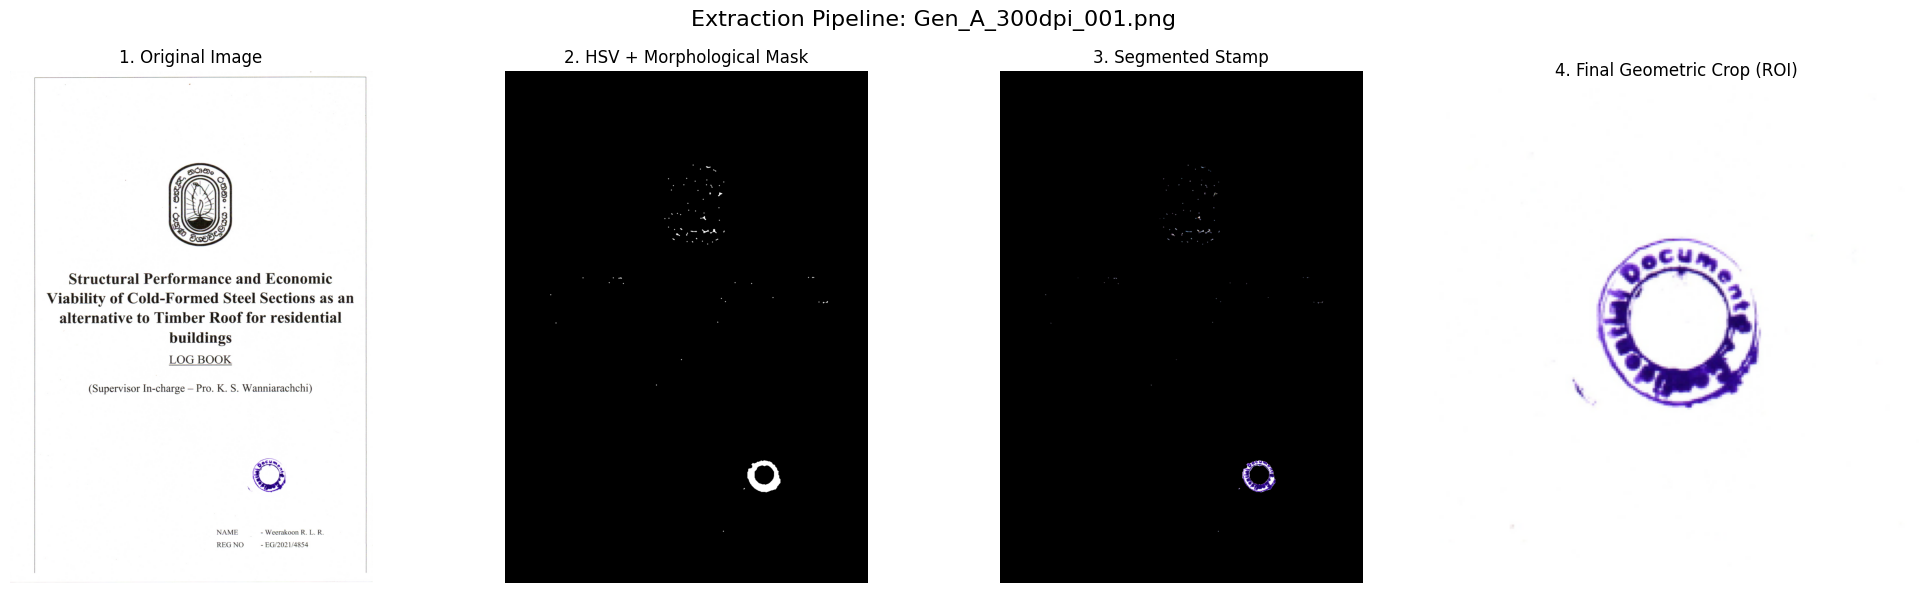

--- FORGED STAMP EXTRACTION ---


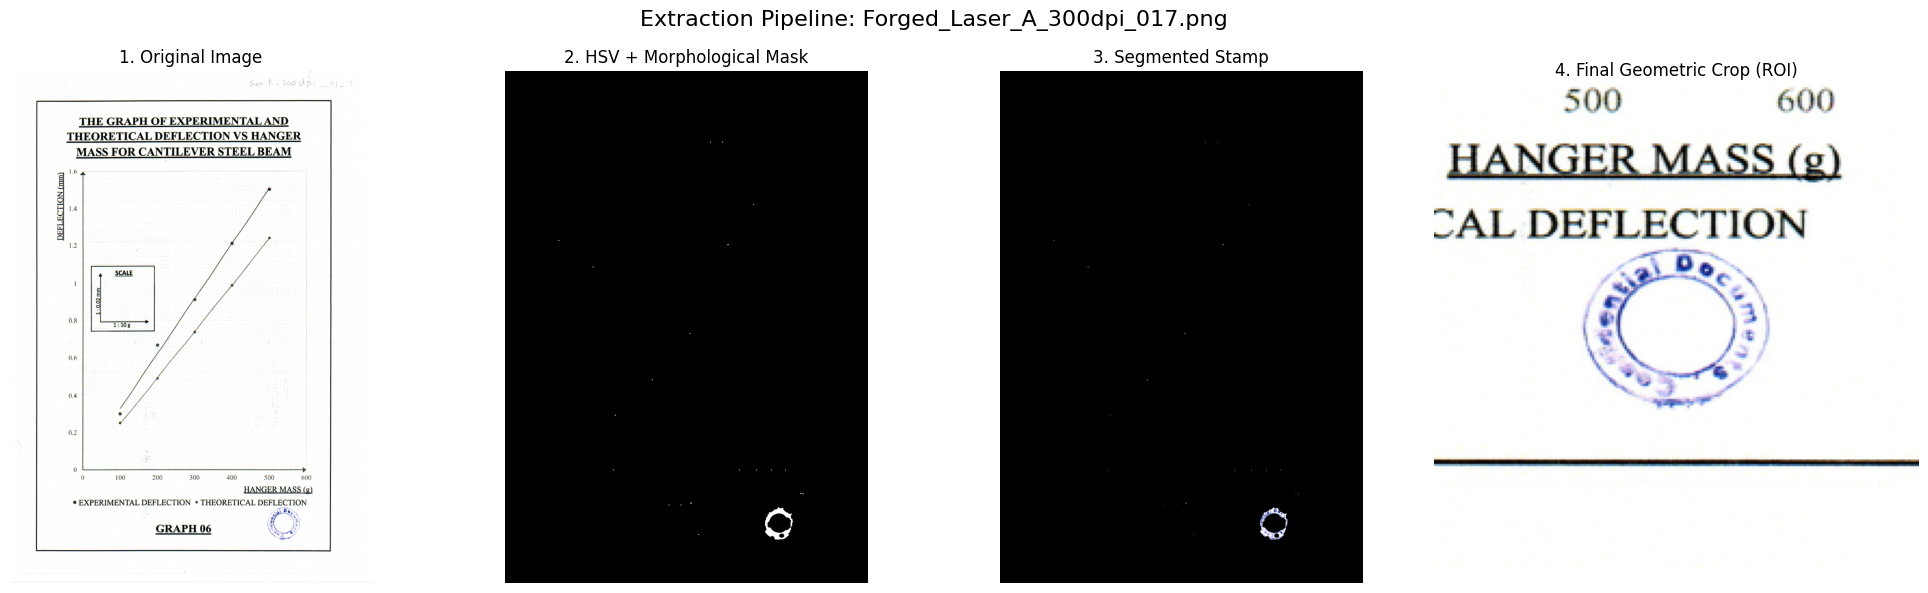

In [5]:
# Grab one genuine and one forged image to demonstrate
genuine_samples = list((DATASET_ROOT / "class_0_genuine").rglob("*.png"))
forged_samples = list((DATASET_ROOT / "class_1_forged").rglob("*.png"))

print("--- GENUINE STAMP EXTRACTION ---")
if genuine_samples:
    plot_extraction_steps(genuine_samples[0])

print("--- FORGED STAMP EXTRACTION ---")
if forged_samples:
    plot_extraction_steps(forged_samples[0])